# Fusion Experiments

This is where I finally compare the unimodal branches against the synthetic multimodal setup, with repeated seeds so I am not over-reading one lucky run. I am running both the same-label pairing and a random-pairing control on purpose. If the apparent fusion gain only survives when the labels are artificially aligned, then that tells me something important about the setup rather than about multimodal learning.


## Notebook Purpose

This notebook runs the exploratory fusion experiments on the synthetic pairs. It compares tabular-only, image-only, early-fusion, and late-fusion baselines across same-label and random-pairing strategies.


## Why This Matters

Fusion metrics are only meaningful when compared against unimodal baselines and pairing controls. Repeating experiments across seeds helps separate stable behaviour from one-off pairing artifacts.


## Load Fusion Inputs

This setup cell loads the published Wisconsin data and the saved patient-level image embeddings. It also defines the repeated seeds used for controlled comparison.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs_v2'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

from src.fusion import (
    load_wisconsin_dataframe,
    run_late_fusion_experiment,
    run_logistic_fusion_experiment,
    summarise_experiment_rows,
)
from src.pairing import build_random_pairs, build_same_label_pairs

wisconsin = load_wisconsin_dataframe(WISCONSIN_ROOT / 'brca.csv')
image_embeddings = pd.read_csv(REPORTS / 'breakhis_patient_level_embeddings.csv')
seeds = [11, 21, 31, 41, 51]
rows = []


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs_v2


## Run Repeated Fusion Experiments

This cell executes the main fusion comparison. For each pairing strategy and seed, it evaluates tabular-only, image-only, early fusion, and late fusion, then saves both raw metric rows and summarized statistics.


In [2]:
for pairing_name, builder in [('same_label', build_same_label_pairs), ('random', build_random_pairs)]:
    for seed in seeds:
        paired = builder(wisconsin, image_embeddings, random_state=seed).paired
        experiments = {
            'tabular_only': run_logistic_fusion_experiment(paired, random_state=seed, feature_prefixes=('tab_',)),
            'image_only': run_logistic_fusion_experiment(paired, random_state=seed, feature_prefixes=('img_img_emb_',)),
            'early_fusion': run_logistic_fusion_experiment(paired, random_state=seed),
            'late_fusion': run_late_fusion_experiment(paired, random_state=seed),
        }
        for experiment_name, result in experiments.items():
            for metric_name, metric_value in result.metrics.items():
                rows.append(
                    {
                        'pairing_type': pairing_name,
                        'seed': seed,
                        'experiment': experiment_name,
                        'metric': metric_name,
                        'value': metric_value,
                    }
                )
results_df = pd.DataFrame(rows)
results_df.to_csv(METRICS / 'synthetic_fusion_experiments.csv', index=False)
summary_df = summarise_experiment_rows(results_df)
summary_df.to_csv(METRICS / 'synthetic_fusion_summary.csv', index=False)
summary_df.head(20)


,pairing_type,experiment,metric,mean,std,min,max
0,random,early_fusion,accuracy,0.970175,0.010002,0.956140,0.982456
1,random,early_fusion,brier_score,0.022838,0.009095,0.014408,0.033308
2,random,early_fusion,f1_score,0.959143,0.013240,0.941176,0.975610
3,random,early_fusion,precision,0.971290,0.025303,0.930233,1.000000
4,random,early_fusion,recall,0.947619,0.010648,0.928571,0.952381
5,random,early_fusion,roc_auc,0.994775,0.004828,0.988757,0.999339
6,random,image_only,accuracy,0.585965,0.036905,0.526316,0.622807
7,random,image_only,brier_score,0.262869,0.017066,0.245995,0.289266
8,random,image_only,f1_score,0.346602,0.073730,0.228571,0.426667
9,random,image_only,precision,0.411399,0.076043,0.285714,0.484848


## Plot Accuracy And ROC-AUC Comparisons

This cell turns the repeated-seed summary into a comparison figure. Accuracy and ROC-AUC are shown side by side because a single metric is not enough to interpret classifier behaviour.


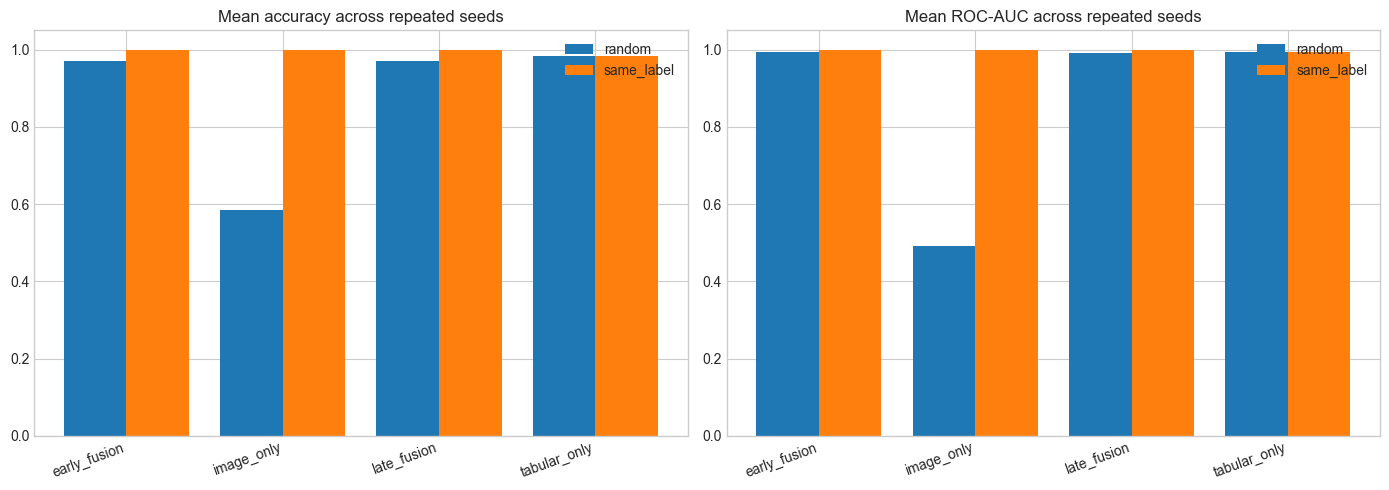

In [3]:
accuracy_plot_df = summary_df[summary_df['metric'] == 'accuracy']
roc_plot_df = summary_df[summary_df['metric'] == 'roc_auc']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric_df, title in [
    (axes[0], accuracy_plot_df, 'Mean accuracy across repeated seeds'),
    (axes[1], roc_plot_df, 'Mean ROC-AUC across repeated seeds'),
]:
    pairings = metric_df['pairing_type'].unique()
    experiments = metric_df['experiment'].unique()
    width = 0.8 / len(pairings)
    x = np.arange(len(experiments))
    for idx, pairing in enumerate(pairings):
        subset = metric_df[metric_df['pairing_type'] == pairing].set_index('experiment').reindex(experiments)
        ax.bar(x + (idx - (len(pairings)-1)/2)*width, subset['mean'], width=width, label=pairing)
    ax.set_xticks(x, experiments)
    ax.set_title(title)
    ax.legend()
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.tight_layout()
fig.savefig(FIGURES / 'fusion_experiment_comparison.png', dpi=300)
plt.show()


## Stability Table

This pivot table exposes mean and standard deviation together. It is useful for discussing whether a result is consistent across seeds or sensitive to synthetic pairing choices.


In [4]:
stability_view = summary_df.pivot_table(index=['pairing_type', 'experiment'], columns='metric', values=['mean', 'std'])
stability_view


mean                                            \
metric                     accuracy brier_score  f1_score precision    recall   
pairing_type experiment                                                         
random       early_fusion  0.970175    0.022838  0.959143  0.971290  0.947619   
             image_only    0.585965    0.262869  0.346602  0.411399  0.300000   
             late_fusion   0.971930    0.079885  0.960488  0.995000  0.928571   
             tabular_only  0.982456    0.016562  0.975727  0.995122  0.957143   
same_label   early_fusion  1.000000    0.001411  1.000000  1.000000  1.000000   
             image_only    1.000000    0.001878  1.000000  1.000000  1.000000   
             late_fusion   0.998246    0.004930  0.997590  1.000000  0.995238   
             tabular_only  0.982456    0.016562  0.975727  0.995122  0.957143   

                                          std                                  \
metric                      roc_auc  accuracy brier_score  f1_score precision   
pairing_type experiment                                                         
random       early_fusion  0.994775  0.010002    0.009095  0.013240  0.025303   
             image_only    0.492427  0.036905    0.017066  0.073730  0.076043   
             late_fusion   0.990410  0.009609    0.006062  0.013813  0.011180   
             tabular_only  0.995040  0.006203    0.005778  0.008521  0.010908   
same_label   early_fusion  1.000000  0.000000    0.000826  0.000000  0.000000   
             image_only    1.000000  0.000000    0.001485  0.000000  0.000000   
             late_fusion   1.000000  0.003923    0.001582  0.005388  0.000000   
             tabular_only  0.995040  0.006203    0.005778  0.008521  0.010908   

                                               
metric                       recall   roc_auc  
pairing_type experiment                        
random       early_fusion  0.010648  0.004828  
             image_only    0.070630  0.057517  
             late_fusion   0.023810  0.005424  
             tabular_only  0.010648  0.005192  
same_label   early_fusion  0.000000  0.000000  
             image_only    0.000000  0.000000  
             late_fusion   0.010648  0.000000  
             tabular_only  0.010648  0.005192

## What the numbers actually say

The same-label pairing scored high enough to make me suspicious, which is exactly why I kept the random control in place. Once the label alignment is broken, the fusion numbers drop sharply. For me that is the clearest result in the whole synthetic study. Most of what looks like a multimodal gain here is really coming from the pairing rule, not from the model discovering anything especially deep across modalities. That is a stronger and more interesting conclusion than pretending the setup proved a real multimodal advantage.


## How This Notebook Supports The Dissertation

This notebook supplies the evidence for the exploratory fusion branch. Its results should be discussed as method-comparison evidence under synthetic constraints, not as proof of clinical multimodal performance.
